# 11 · Auditory and visual evoked responses

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Explore a different event-related paradigm, compare EEG responses to auditory and visual stimuli and distinguish sensory decoding from intentional BCI control.

**Data:** MNE sample auditory/visual EEG; large optional download

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

An auditory and a visual stimulus produce different averaged responses. What does that observation establish, and what additional design would be needed to turn it into a BCI? We use an ERP comparison to practice careful interpretation of event-locked signals.

### By the end you should be able to

- Explain why averaging improves an event-locked response under specific noise assumptions.
- Distinguish peak latency, peak amplitude and window-mean amplitude.
- Calculate global field power across EEG sensors.
- Separate stimulus-response analysis from intentional communication.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### What an average estimates

For trial $n$, write $x_n(t)=s(t)+\epsilon_n(t)$. If the response $s$ is stable and the noise is independent across trials with zero mean, the trial average estimates $s$, while the standard deviation of its noise decreases as $1/\sqrt{N}$. Real data can violate all three assumptions: response amplitudes vary, latency jitters, and neighboring trials share slow drift. Averaging improves visibility but does not guarantee an unbiased or perfectly repeatable waveform.

An `Evoked` object retains channel metadata and time coordinates while collapsing the trial axis. Its `nave` records how many epochs contributed. Compare conditions with attention to retained counts and rejection rules. A smoother condition average may simply contain more trials.

### Describe amplitude and latency precisely

A peak amplitude depends on polarity, channel, time interval and noise. Searching every time point and channel for the largest difference selects an extreme value and inflates the apparent effect. A pre-specified window mean is often more stable for a teaching comparison:

$$A_{nc}=\frac{1}{|W|}\sum_{t\in W}x_{nct}.$$

Latency jitter can reduce the peak of an average without changing each trial's response amplitude. Thus a smaller average peak need not mean a weaker single-trial response. Use a simulation to separate these mechanisms before interpreting real conditions.

### A sensor-wide summary

Global field power (GFP) for EEG is the standard deviation across sensors at each time:

$$GFP(t)=\sqrt{\frac{1}{C}\sum_c[x_c(t)-\bar x(t)]^2}.$$

It summarizes the spatial spread of measured voltage, is nonnegative, and is unchanged by subtracting the same reference value from every included channel. Channel selection still matters: a bad channel can dominate GFP, and different sensor sets can change its value. GFP contains no information about the sign or detailed spatial pattern of a response. It is a sensor-level descriptor, not source reconstruction.

### From an ERP experiment to a BCI

The MNE sample data in this lesson contain auditory and visual stimulation. Comparing their responses teaches event mapping, averaging and sensor-level measurement. It is not an oddball P300 speller and does not demonstrate voluntary command selection. For an auditory-attention BCI, one would need a protocol that links intended choices to attended stimuli, labels that reflect that intent and a held-out test of the resulting decoder.

The distinction matters because decoding which stimulus was delivered can be much easier than decoding which stimulus a person chose to attend. A convincing BCI evaluation must match the claimed control variable. Keep this lesson descriptive; use the dedicated P300 and imagery datasets for the corresponding decoding claims.

### Worked example · averaging independent noise

Simulate many averages for different trial counts and compare their standard deviations.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_rng=np.random.default_rng(613)
for n_trials in [1,4,16,64]:
    averages=demo_rng.normal(size=(2000,n_trials)).mean(axis=1)
    print(n_trials,'Observed SD:',round(averages.std(),3),'Expected:',1/np.sqrt(n_trials))

1 Observed SD: 1.0 Expected: 1.0
4 Observed SD: 0.489 Expected: 0.5
16 Observed SD: 0.253 Expected: 0.25
64 Observed SD: 0.126 Expected: 0.125


**Read the result.** The square-root law relies on independent zero-mean noise. Repeated copies of the same noisy trial would not provide this improvement.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · latency jitter

Average identical Gaussian responses with varying latency. Compare their peak heights.

**Before running:** state your prediction and the assumption behind it.

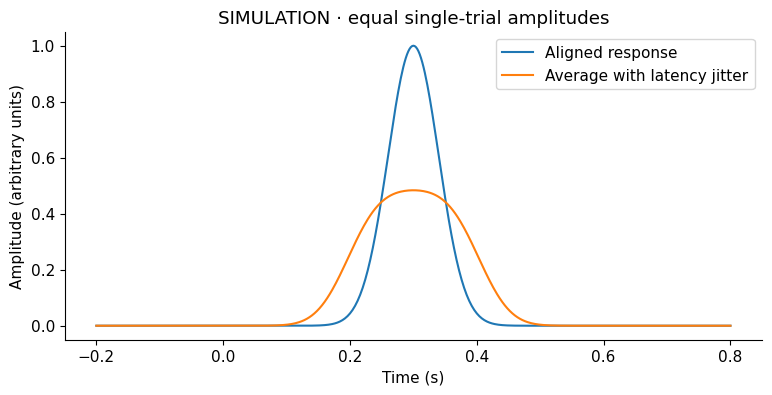

In [3]:
demo_t=np.linspace(-.2,.8,501)
demo_locked=np.exp(-.5*((demo_t-.3)/.04)**2)
demo_jittered=np.stack([np.exp(-.5*((demo_t-(.3+d))/.04)**2) for d in np.linspace(-.1,.1,40)])
fig,ax=plt.subplots()
ax.plot(demo_t,demo_locked,label='Aligned response')
ax.plot(demo_t,demo_jittered.mean(axis=0),label='Average with latency jitter')
ax.set(xlabel='Time (s)',ylabel='Amplitude (arbitrary units)',title='SIMULATION · equal single-trial amplitudes')
ax.legend();plt.show()

**Read the result.** The lower average peak results from temporal misalignment, even though each trial has the same peak amplitude.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · GFP ignores a common reference

Compute sensor standard deviation before and after subtracting a shared reference.

**Before running:** state your prediction and the assumption behind it.

In [4]:
demo_sensor=np.array([[1.,2.],[-1.,0.],[3.,4.]])
demo_reference=np.array([10.,-5.])
print('GFP:',demo_sensor.std(axis=0))
assert np.allclose(demo_sensor.std(axis=0),(demo_sensor-demo_reference).std(axis=0))

GFP: [1.63299316 1.63299316]


**Read the result.** A common offset cancels in the sensor deviations. This property does not protect against a bad channel or inconsistent channel selection.

**Pause and explain:** point to one computed value that supports this interpretation.

### Checkpoint · averaging axis

Use a small trial × channel × time array and contrast averaging trials with averaging channels.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_data=np.arange(60.).reshape(5,3,4)
print('ERP shape:',demo_data.mean(axis=0).shape)
print('Trial-wise channel mean shape:',demo_data.mean(axis=1).shape)

ERP shape: (3, 4)
Trial-wise channel mean shape: (5, 4)


**Read the result.** Both operations run successfully, but only the first produces one average waveform per channel.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

An evoked response is time-locked to an event and phase-consistent enough to survive averaging. Induced activity can change power without a consistent phase, disappearing in the ERP while remaining in a time-frequency analysis.

For condition means $\bar X_A,\bar X_V$, a contrast is $D=\bar X_A-\bar X_V$. A contrast plot does not by itself establish statistical significance: channels and time samples are correlated and exploratory testing involves multiplicity. The standard error $s(t)/\sqrt{N}$ assumes independent observations; correlated trials and shared artifacts weaken that assumption.

MNE’s sample dataset contains auditory and visual events recorded with MEG and EEG. We use EEG only to keep the lesson CPU-friendly. This is **not** an auditory P300 speller, and decoding stimulus modality is not equivalent to decoding a user’s intention. To design an auditory BCI, add a task requiring selective attention and explicit target metadata.

## Load the sample recording
The native archive is large: budget roughly 2 GB disk plus extraction space. Download once before class.

The native sample archive is larger than the other lessons. Events are mapped to auditory and visual conditions explicitly; EEG and EOG types support separate rejection thresholds. The recording is a stimulus-response example, not an intentional-selection BCI.

In [6]:
path=mne.datasets.sample.data_path(path=DATA_ROOT,update_path=False)
raw=mne.io.read_raw_fif(path/'MEG'/'sample'/'sample_audvis_raw.fif',preload=False)
events=mne.find_events(raw,stim_channel='STI 014')
raw.pick(['eeg','eog']).load_data()
raw.set_eeg_reference('average',projection=False)
raw.filter(.5,30)
epochs=mne.Epochs(raw,events,{'auditory/left':1,'auditory/right':2,
                            'visual/left':3,'visual/right':4},-.2,.6,
                  baseline=(-.2,0),reject={'eeg':150e-6,'eog':250e-6},preload=True)
print({name:len(epochs[name]) for name in ['auditory','visual']})

{'auditory': 136, 'visual': 139}


### Inspect and interpret

Inspect retained counts and the event dictionary. Note that any auditory/visual comparison includes the actual acquisition and rejection choices stated here.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Compare evoked responses
A channel-average trace can cancel spatially opposed fields. Use the global field power (sensor standard deviation) to summarize response magnitude.

GFP summarizes the across-sensor spread of each condition average. It avoids cancellation that can occur in a signed channel mean, but it also discards the detailed spatial pattern and polarity.

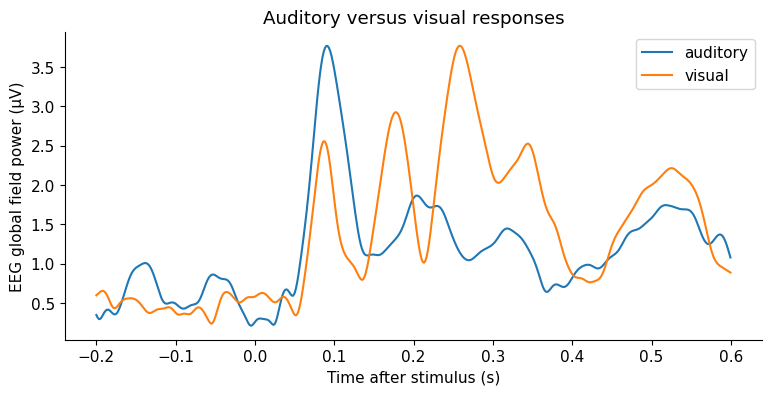

Rejected fraction: 0.04844290657439443


In [7]:
fig,ax=plt.subplots()
for condition in ['auditory','visual']:
    evoked=epochs[condition].average(picks='eeg')
    gfp=evoked.data.std(axis=0)*1e6
    ax.plot(evoked.times,gfp,label=condition)
ax.set(xlabel='Time after stimulus (s)',ylabel='EEG global field power (µV)',title='Auditory versus visual responses')
ax.legend(); plt.show()
print('Rejected fraction:',1-len(epochs)/sum(np.isin(events[:,2],[1,2,3,4])))

### Inspect and interpret

Describe when each condition differs from its baseline level. Explain why GFP alone cannot tell which sensor is positive or whether a person intended a command.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · GFP function

Implement global_field_power for channel × time input using population standard deviation.

In [8]:
def global_field_power(values):
    # TODO: reduce sensors, retaining time.
    return None

In [9]:
answer=global_field_power(np.array([[1.,2.],[-1.,0.],[3.,4.]]))
if answer is not None:
    assert np.allclose(answer,np.sqrt(8/3)); print('GFP checks passed.')
else: print('Exercise pending: implement global_field_power.')

Exercise pending: implement global_field_power.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Count matching

Compare auditory and visual averages using equal trial counts chosen reproducibly. Report what changes and what remains stable.

In [10]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Window measurement

Pre-specify a channel and latency window, then calculate single-trial mean amplitudes. Plot distributions instead of only the averages.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Jitter experiment

Increase simulated latency jitter and plot average peak amplitude. Explain why this does not prove a change in neural response strength.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · BCI redesign

Propose an auditory attention experiment: choices, event markers, target labels, controls, calibration and held-out evaluation.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Write one supported conclusion from the real ERP comparison and one tempting conclusion the data do not establish.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[MNE sample dataset](https://mne.tools/stable/documentation/datasets.html#sample) · [ERP analysis](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.